# Conditional Diffusion (DDPM) on Fashion-MNIST

Stable Diffusion uses a denoising UNet trained with a DDPM scheduler. This notebook applies the same idea on Fashion-MNIST with class conditioning, mirroring the setup in `cvae_fashion_mnist.ipynb`.

## Setup

In [1]:
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from diffusers import DDPMScheduler, UNet2DModel
import matplotlib.pyplot as plt

torch.manual_seed(0)
device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)
print(device)

NUM_CLASSES = 10
IMAGE_SIZE = 28
BATCH_SIZE = 128
EPOCHS = 10
LR = 1e-3
NUM_TRAIN_TIMESTEPS = 1000
INFERENCE_STEPS = 200

CLASS_NAMES = [
    "T-shirt", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot",
]

/opt/miniconda3/envs/vae/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


mps


## Data

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
])

train_data = datasets.FashionMNIST("./data", train=True, download=True, transform=transform)
test_data = datasets.FashionMNIST("./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE)

print(len(train_data), len(test_data))

60000 10000


## Model

In [3]:
unet = UNet2DModel(
    sample_size=IMAGE_SIZE,
    in_channels=1,
    out_channels=1,
    layers_per_block=2,
    block_out_channels=(64, 128, 256),
    down_block_types=("DownBlock2D", "DownBlock2D", "DownBlock2D"),
    up_block_types=("UpBlock2D", "UpBlock2D", "UpBlock2D"),
    num_class_embeds=NUM_CLASSES,
).to(device)

scheduler = DDPMScheduler(num_train_timesteps=NUM_TRAIN_TIMESTEPS)
optimizer = torch.optim.AdamW(unet.parameters(), lr=LR)

print(sum(p.numel() for p in unet.parameters()))

14406785


## Train

epoch 1: 0.0672
epoch 2: 0.0448
epoch 3: 0.0416
epoch 4: 0.0395
epoch 5: 0.0394
epoch 6: 0.0386
epoch 7: 0.0381
epoch 8: 0.0384
epoch 9: 0.0373
epoch 10: 0.0370


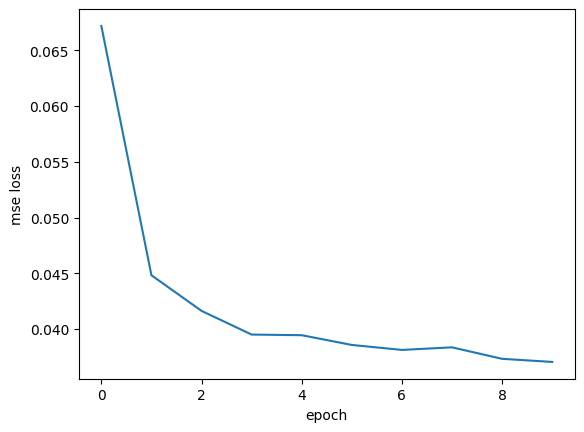

In [4]:
losses = []

for epoch in range(EPOCHS):
    unet.train()
    total_loss = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        noise = torch.randn_like(images)
        timesteps = torch.randint(
            0, scheduler.config.num_train_timesteps, (images.size(0),), device=device
        ).long()
        noisy_images = scheduler.add_noise(images, noise, timesteps)

        noise_pred = unet(noisy_images, timesteps, class_labels=labels).sample
        loss = F.mse_loss(noise_pred, noise)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    losses.append(avg_loss)
    print(f"epoch {epoch + 1}: {avg_loss:.4f}")

plt.plot(losses)
plt.xlabel("epoch")
plt.ylabel("mse loss")
plt.show()

## Denoise

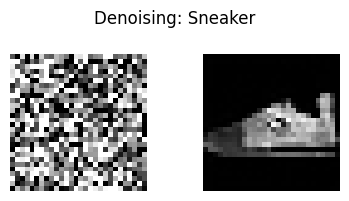

In [6]:
def to_display(img):
    return img.squeeze().cpu().clamp(-1, 1).add(1).div(2)


def denoise_sample(class_idx, steps=INFERENCE_STEPS, seed=0):
    unet.eval()
    scheduler.set_timesteps(steps)

    generator = torch.Generator(device=device).manual_seed(seed)
    sample = torch.randn(
        1, 1, IMAGE_SIZE, IMAGE_SIZE, generator=generator, device=device
    )
    label = torch.tensor([class_idx], device=device)

    trajectory = [to_display(sample)]
    with torch.no_grad():
        for t in scheduler.timesteps:
            noise_pred = unet(sample, t, class_labels=label).sample
            sample = scheduler.step(noise_pred, t, sample).prev_sample
            if t in {scheduler.timesteps[0], scheduler.timesteps[len(scheduler.timesteps) // 2], scheduler.timesteps[-1]}:
                trajectory.append(to_display(sample))

    trajectory.append(to_display(sample))
    return trajectory


steps = denoise_sample(class_idx=7)
fig, axes = plt.subplots(1, len(steps), figsize=(2 * len(steps), 2))
for ax, img in zip(axes, steps):
    ax.imshow(img, cmap="gray")
    ax.axis("off")
plt.suptitle(f"Denoising: {CLASS_NAMES[7]}")
plt.tight_layout()
plt.show()

## Generate

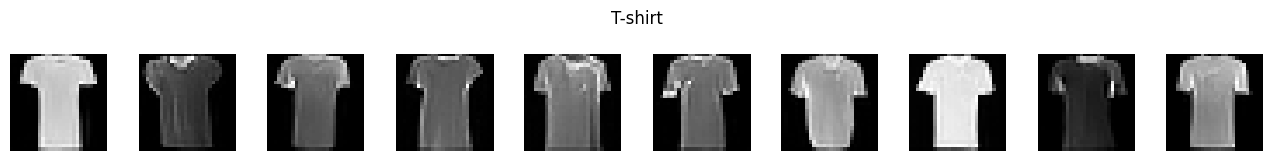

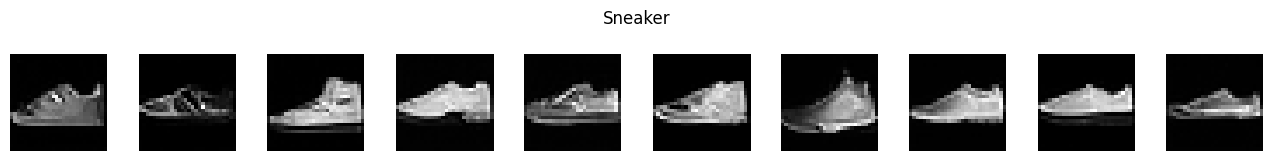

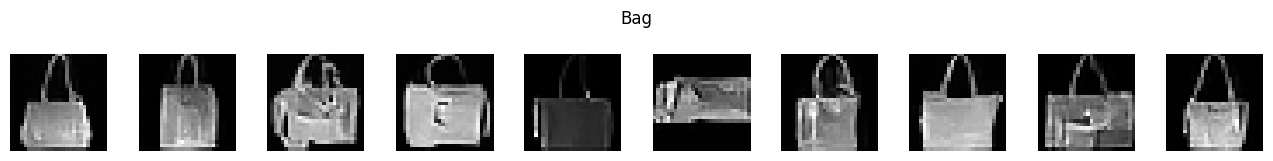

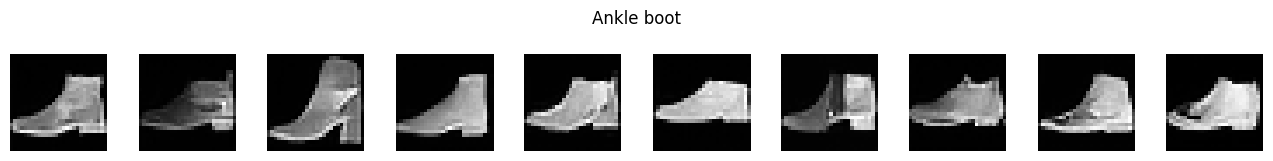

In [7]:
def generate(class_idx, n=10, steps=INFERENCE_STEPS, seed=0):
    unet.eval()
    scheduler.set_timesteps(steps)

    generator = torch.Generator(device=device).manual_seed(seed)
    samples = torch.randn(
        n, 1, IMAGE_SIZE, IMAGE_SIZE, generator=generator, device=device
    )
    labels = torch.full((n,), class_idx, dtype=torch.long, device=device)

    with torch.no_grad():
        for t in scheduler.timesteps:
            noise_pred = unet(samples, t, class_labels=labels).sample
            samples = scheduler.step(noise_pred, t, samples).prev_sample

    return to_display(samples).numpy()


def show_generated(class_idx, n=10):
    imgs = generate(class_idx, n)
    fig, axes = plt.subplots(1, n, figsize=(1.3 * n, 1.6))
    for i, ax in enumerate(axes):
        ax.imshow(imgs[i], cmap="gray")
        ax.axis("off")
    plt.suptitle(CLASS_NAMES[class_idx])
    plt.tight_layout()
    plt.show()


for class_idx in [0, 7, 8, 9]:
    show_generated(class_idx)

## Compare with real samples

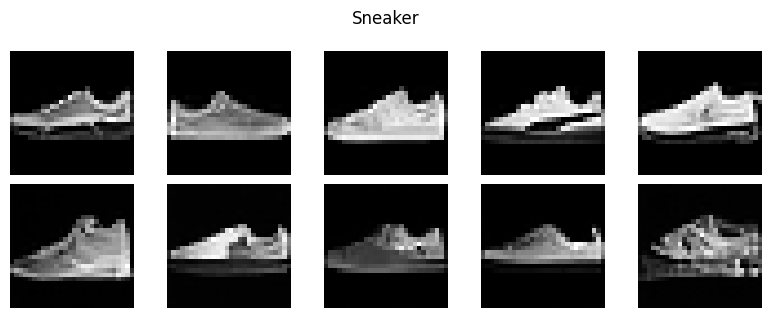

In [8]:
class_idx = 7
real_imgs = []
for images, labels in test_loader:
    mask = labels == class_idx
    if mask.any():
        real_imgs.append(images[mask][:5])
    if sum(len(x) for x in real_imgs) >= 5:
        break

real_imgs = torch.cat(real_imgs)[:5]
fake_imgs = generate(class_idx, n=5, seed=1)

fig, axes = plt.subplots(2, 5, figsize=(8, 3.2))
for i in range(5):
    axes[0, i].imshow(to_display(real_imgs[i]), cmap="gray")
    axes[0, i].axis("off")
    axes[1, i].imshow(fake_imgs[i], cmap="gray")
    axes[1, i].axis("off")
axes[0, 0].set_ylabel("real")
axes[1, 0].set_ylabel("generated")
plt.suptitle(CLASS_NAMES[class_idx])
plt.tight_layout()
plt.show()